# Model Comparison :)

### Models used for comparison
- Linear Regression (baseline)
- Extra Trees

### Evaluation metrics
- RMSE
- R²

## import + load dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor

In [23]:
# load new dataset
df = pd.read_csv("../data/cleaned-engineered.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(614534, 26)
['List Year', 'Date Recorded', 'Town', 'Assessed Value', 'Sale Amount', 'Property Type', 'Residential Type', 'Location', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Assessment Ratio', 'Assessment Gap', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC', 'Dist To Hartford', 'Dist To Boston', 'Approx Dist To Coast', 'Town Median Sale Amount', 'Town Avg Assessment Ratio', 'Town Avg Sale Amount', 'Town Market Strength', 'Luxury Home']


,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Property Type,Residential Type,Location,Sale Year,Sale Month,...,Longitude,Dist To NYC,Dist To Hartford,Dist To Boston,Approx Dist To Coast,Town Median Sale Amount,Town Avg Assessment Ratio,Town Avg Sale Amount,Town Market Strength,Luxury Home
0,2010,2010-10-02,Norwalk,339640.0,265000.0,Residential,Single Family,POINT (-73.408 41.118),2010,10,...,-73.408,41.936910,58.745280,148.427562,8.142,420000.0,1.876569,617242.675586,1.650295,0
1,2010,2010-10-03,Milford,674350.0,788000.0,Residential,Single Family,POINT (-73.057 41.222),2010,10,...,-73.057,60.737843,42.495549,129.526272,15.318,287000.0,1.496553,344579.129171,1.127701,0
2,2010,2010-10-04,Bridgeport,132250.0,148000.0,Residential,Single Family,POINT (-73.195 41.186),2010,10,...,-73.195,53.480470,48.310972,136.729259,12.834,160000.0,1.492121,212777.367623,0.628684,0
3,2010,2010-10-04,Bristol,99610.0,32000.0,Residential,Single Family,POINT (-72.94 41.671),2010,10,...,-72.940,86.341970,15.229990,107.661631,46.299,185000.0,1.731108,211111.211163,0.726916,0
4,2010,2010-10-04,Bridgeport,132260.0,110000.0,Residential,Single Family,POINT (-73.195 41.186),2010,10,...,-73.195,53.480470,48.310972,136.729259,12.834,160000.0,1.492121,212777.367623,0.628684,0


## decide preprocessing

In [24]:
# outlier trimming used in tree notebook
df = df[(df["Sale Amount"] >= 10000) & (df["Sale Amount"] <= 5000000)].copy()

print("rows after outlier trimming:", df.shape[0])

rows after outlier trimming: 609490


In [25]:
leakage_cols = [
    "Assessment Ratio",
    "Assessment Gap",
    "Town Avg Sale Amount",
    "Town Median Sale Amount",
    "Luxury Home",
    "Town Avg Assessment Ratio",
    "Town Market Strength"
]

existing_leakage_cols = [col for col in leakage_cols if col in df.columns]
df = df.drop(columns=existing_leakage_cols)

print("dropped leakage columns:", existing_leakage_cols)

dropped leakage columns: ['Assessment Ratio', 'Assessment Gap', 'Town Avg Sale Amount', 'Town Median Sale Amount', 'Luxury Home', 'Town Avg Assessment Ratio', 'Town Market Strength']


## define target + feature cols

In [26]:
# exclude target and other non-feature columns
drop_cols = ["Sale Amount", "Date Recorded", "Address", "Location"]

drop_cols = [col for col in drop_cols if col in df.columns]
X = df.drop(columns=drop_cols)
y = df["Sale Amount"]

print("feature count:", X.shape[1])
print(X.columns.tolist())

feature count: 16
['List Year', 'Town', 'Assessed Value', 'Property Type', 'Residential Type', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC', 'Dist To Hartford', 'Dist To Boston', 'Approx Dist To Coast']


In [27]:
# categorical vs numeric cols
categorical_cols = [col for col in ["Town", "Property Type", "Residential Type"] if col in X.columns]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("categorical columns:", categorical_cols)
print("numeric columns:", numeric_cols)

bad_numeric = X[numeric_cols].select_dtypes(include=["object"]).columns.tolist()
print("object columns accidentally in numeric_cols:", bad_numeric)


categorical columns: ['Town', 'Property Type', 'Residential Type']
numeric columns: ['List Year', 'Assessed Value', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC', 'Dist To Hartford', 'Dist To Boston', 'Approx Dist To Coast']
object columns accidentally in numeric_cols: []


## train test split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("training rows:", X_train.shape[0])
print("testing rows:", X_test.shape[0])

training rows: 426643
testing rows: 182847


In [29]:
y_train_log = np.log1p(y_train)

## preprocessing pipeline

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

## define model

In [31]:
# linear regression (baseline) and extra trees (best model from tree notebook)
models = {
    "LinearRegression": LinearRegression(),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=50,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    )
}

## train + evaluate models

In [32]:
print("fitting preprocessor...")

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("transformed training shape:", X_train_proc.shape)
print("transformed testing shape:", X_test_proc.shape)

fitting preprocessor...
transformed training shape: (426643, 193)
transformed testing shape: (182847, 193)


### cell below takes a hot min to run so beware (like 30 mins)

In [33]:
results = {}
fitted_models = {}

for name, regressor in models.items():
    print(f"training {name}...")

    regressor.fit(X_train_proc, y_train_log)

    y_pred_log = regressor.predict(X_test_proc)
    y_pred = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "RMSE": rmse,
        "R2": r2
    }

    fitted_models[name] = regressor

results_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
    .sort_values(by="R2", ascending=False)
)

results_df

training LinearRegression...
training ExtraTrees...


,Model,RMSE,R2
1,ExtraTrees,186622.032361,0.823120
0,LinearRegression,434144.440365,0.042758


## model comparison

In [44]:
# table
results_df = results_df.sort_values(by="R2", ascending=False)
results_df

,Model,RMSE,R2
1,ExtraTrees,186622.032361,0.823120
0,LinearRegression,434144.440365,0.042758


In [45]:
import os
os.makedirs("../results", exist_ok=True)

In [46]:
results_df.to_csv("../results/model_comparison.csv", index=False)

## plot comparison

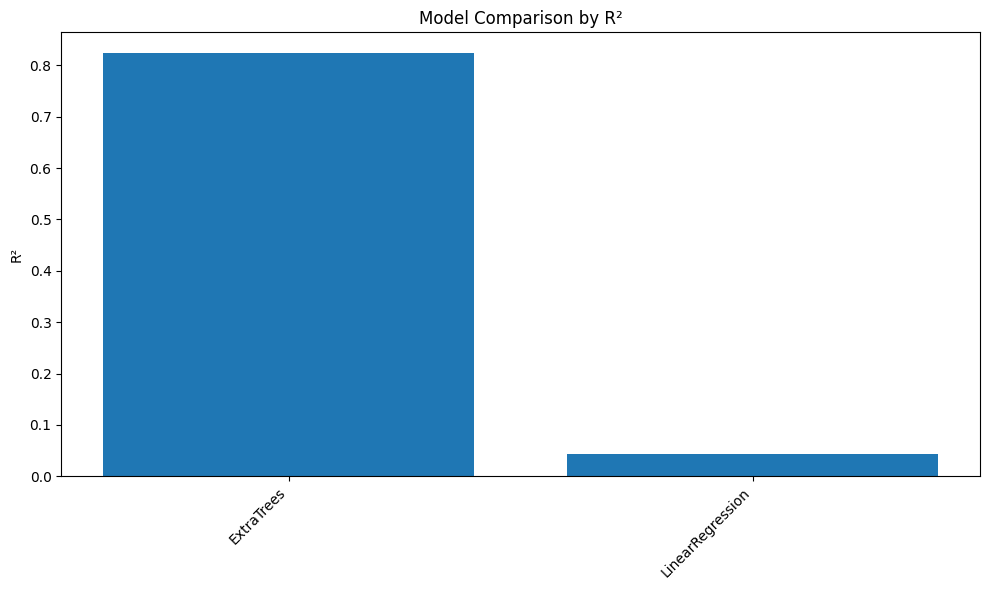

In [47]:
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Model Comparison by R²")
plt.tight_layout()
plt.show()

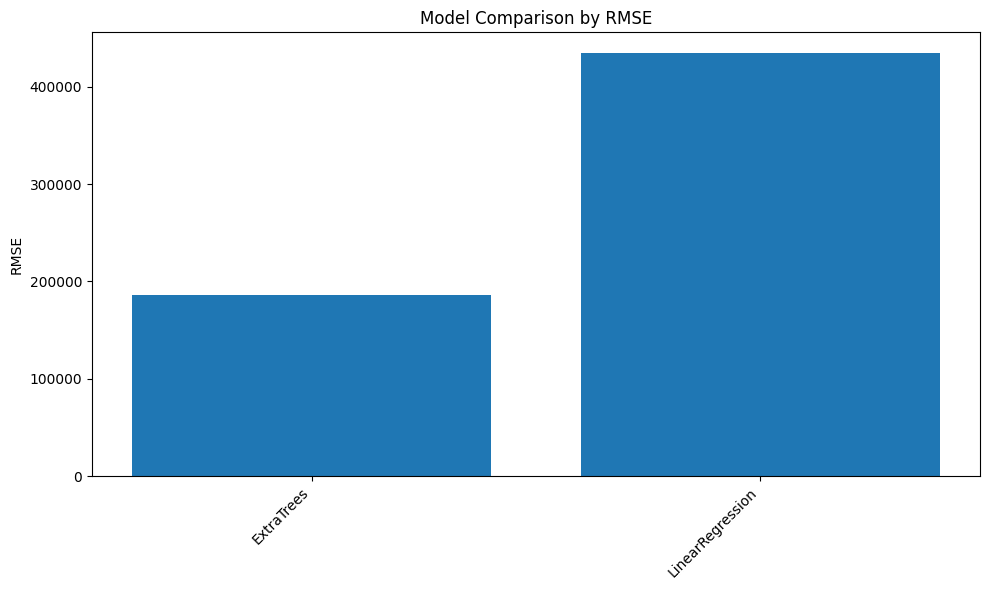

In [48]:
# RMSE
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.tight_layout()
plt.show()

## feature importance for best tree model

In [49]:
# extratrees is our best model
best_model = fitted_models["ExtraTrees"]

feature_names = preprocessor.get_feature_names_out()
importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
6,num__Log Assessed Value,0.291544
1,num__Assessed Value,0.181448
9,num__Dist To NYC,0.044626
11,num__Dist To Boston,0.042572
190,cat__Residential Type_Single Family,0.042318
0,num__List Year,0.041416
2,num__Sale Year,0.038506
8,num__Longitude,0.033079
5,num__Sale Day Of Year,0.029698
10,num__Dist To Hartford,0.029444


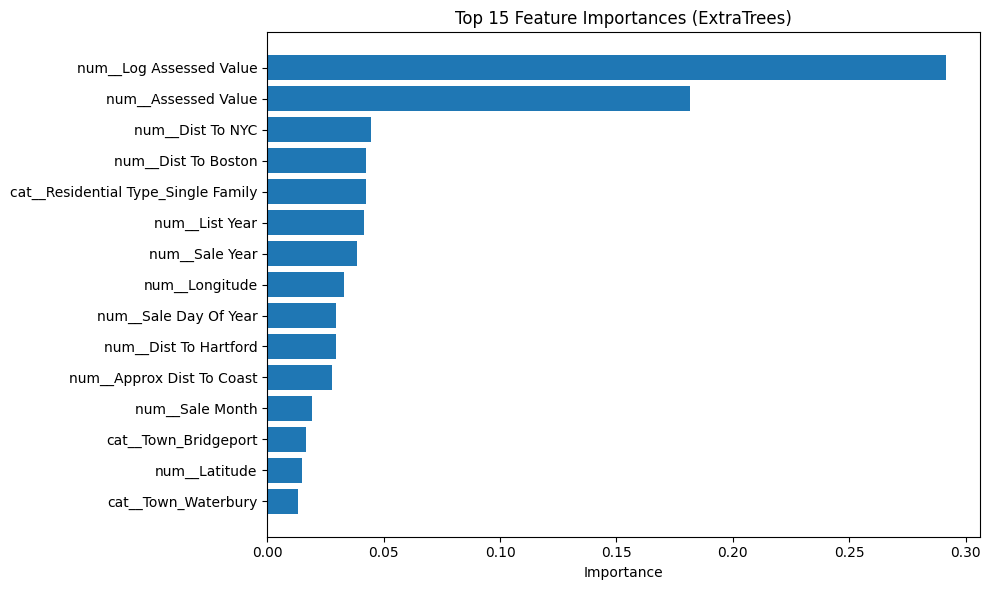

In [50]:
# plot top 15
top_k = 15
top_df = importance_df.head(top_k).sort_values(by="Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_df["Feature"], top_df["Importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (ExtraTrees)")
plt.tight_layout()
plt.show()

In [51]:
importance_df.to_csv("../results/feature_importance_extratrees.csv", index=False)

## prediction scatterplot for best model (extratrees)

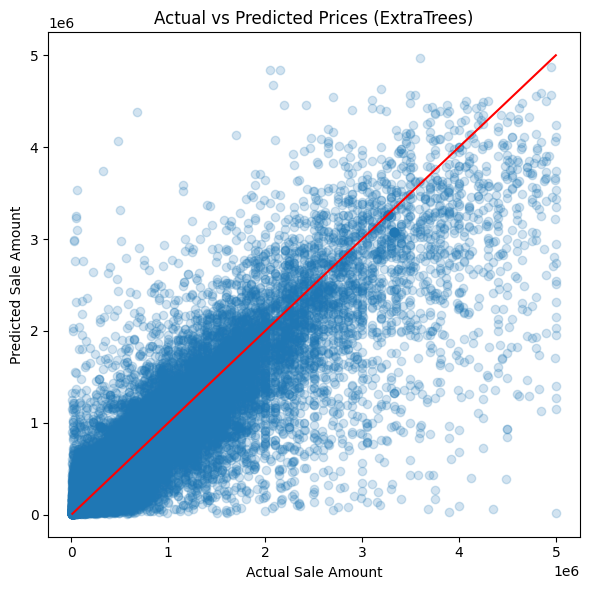

In [52]:
y_pred_log = best_model.predict(X_test_proc)
y_pred = np.expm1(y_pred_log)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Sale Amount")
plt.ylabel("Predicted Sale Amount")
plt.title("Actual vs Predicted Prices (ExtraTrees)")
plt.tight_layout()
plt.show()

# Results

- ExtraTrees model outperforms the baseline linear regression model significantly. 

- Linear Regression
    - RMSE: 434144
    - R^2: 0.0428
- ExtraTrees
    - RMSE: 186622
    - R^2: 0.823

- Model improved significantly, 2.3x lower RMSE + R^2 from 0.04 -> 0.823
- Linear regression fails to capture the complex relationships and features that determine housing prices, while tree-based models can effectively represent nonlinear relationships and interactions
- This indicates that nonlinear relationships and interactions between features are crucial for understanding and predicting housing prices accurately
